<a href="https://colab.research.google.com/github/yxyang0820/SDS365_Assignments/blob/main/assignments/assn5/assn5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intermediate Machine Learning: Assignment 5

**Deadline**

Assignment 5 is due Thursday, December 4 by 11:59pm. Late work will not be accepted as per the course policies (see the Syllabus and Course policies on Canvas).

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. Acknowledge any use of an AI system such as ChatGPT or Copilot.

You should start early so that you have time to get help if you're stuck. The drop-in office hours schedule can be found on Canvas. You can also post questions or start discussions on Ed Discussion. The assignment may look long at first glance, but the problems are broken up into steps that should help you to make steady progress.

**Submission**

Submit your assignment as a pdf file on Gradescope, and as a notebook (.ipynb) on Canvas. You can access Gradescope through Canvas on the left-side of the class home page. The problems in each homework assignment are numbered. Note: When submitting on Gradescope, please select the correct pages of your pdf that correspond to each problem. This will allow graders to more easily find your complete solution to each problem.

To produce the .pdf, please convert to html and then print to pdf. (You may want to use your pdf print menu to scale the pages to be sure that cells are not truncated.) To convert to html, you can use this [converter notebook](https://colab.research.google.com/github/YData123/sds365-fa25/blob/main/assignments/Convert_ipynb_to_HTML_in_Colab.ipynb).

You should start early so that you have time to get help if you're stuck. The drop-in office hours schedule can be found on Canvas. You can also post questions or start discussions on Ed Discussion. The assignment may look long at first glance, but the problems are broken up into steps that should help you to make steady progress.

**Topics**

 * RNNs and GRUs
 * Transformers

After doing this assignment you will have a working knowledge of RNNs and Transformers, and more solid Python skills.

## Problem 1: Elephants Can Remember (25 points)



![ECR](https://upload.wikimedia.org/wikipedia/en/e/e3/Elephants_can_Remember_First_Edition_Cover_1972.jpg)

In this problem, we will work with "vanilla" Recurrent Neural Networks (RNNs) and Recurrent Neural Networks with Gated Recurrent Units (GRUs). The models in this part of the assignment will be character-based models, trained on an extract of the book [Elephants Can Remember](https://en.wikipedia.org/wiki/Elephants_Can_Remember) by Agatha Christie. To reduce the size of our vocabulary, the text is pre-processed by converting the letters to lower case and removing numbers. The code below shows some information about our training and test set. All the necessary files for this problem are available on [github](https://github.com/YData123/sds365-fa25/tree/main/assignments/assn5).


In [1]:
import numpy as np
from tqdm import tqdm
import tensorflow as tf
import random
import json

# Ensure tf.keras is the main keras module
# import tensorflow.keras as keras # This line is no longer strictly necessary if all components are explicitly imported below

from tensorflow.keras.models import Sequential, model_from_json
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.layers import GRU, SimpleRNN

In [2]:
from google.colab import drive
drive.mount('/content/drive')
data_path ='/content/drive/MyDrive/SDS365/assn5/'

... # set to the path where you store the assignment files from github
                # e.g., '/content/drive/MyDrive/SDS365/assn5/'

Mounted at /content/drive


Ellipsis

In [3]:
with open(data_path + 'gru_problem/Agatha_Christie_train.txt', 'r') as file:
    train_text = file.read()

with open(data_path + 'gru_problem/Agatha_Christie_test.txt', 'r') as file:
    test_text = file.read()

vocabulary = sorted(list(set(train_text + test_text)))
vocab_size = len(vocabulary)

# Dictionaries to go from a character to index and vice versa
char_to_indices = dict((c, i) for i, c in enumerate(vocabulary))
indices_to_char = dict((i, c) for i, c in enumerate(vocabulary))

In [4]:
# The first 500 characters of our training set
train_text[0:500]

'mrs. oliver looked at herself in the glass. she gave a brief, sideways look towards the clock on the mantelpiece, which she had some idea was twenty minutes slow. then she resumed her study of her coiffure. the trouble with mrs. oliver was--and she admitted it freely--that her styles of hairdressing were always being changed. she had tried almost everything in turn. a severe pompadour at one time, then a wind-swept style where you brushed back your locks to display an intellectual brow, at least'

In [5]:
print("The vocabulary contains", vocab_size, "characters")
print("The training set contains", len(train_text) ,"characters")
print("The test set contains", len(test_text) ,"characters")

The vocabulary contains 44 characters
The training set contains 262174 characters
The test set contains 7209 characters


### Problem 1.1: The Diversity of Language Models

Before jumping into coding, let's start with comparing the language models we will be using in this assigment.

1. Describe the differences between a Vanilla RNN and a GRU network. In your explanation, make sure you mention the issues with vanilla RNNs and how GRUs try to solve them.

In [ ]:
# Your markdown here


A vanilla RNN updates its hidden state in the same simple way at every time step, so information from far in the past tends to get lost because of vanishing (or exploding) gradients, making long-range dependencies hard to learn.


A GRU adds gates that learn when to keep, update, or reset parts of the hidden state, so important information can be stored for many steps and passed forward more directly, which helps with long-range memory and vanishing gradients.


2. Describe at least two advantages of a character based language model over a word based language model.

In [ ]:
# Your markdown here

Character-based language models have a tiny vocabulary, so they need fewer parameters and never run into “unknown word” problems. They can also naturally generate and understand rare or new words, names, and morphologically complex forms by composing them from characters, instead of being limited to a fixed word list.


### Problem 1.2: Generating Text with the Vanilla RNN

The code below loads in a pretrained vanilla RNN model with two layers. The model is set up exactly like in the lecture slides (with tanh activation layers in the recurrent layers) with the addition of biases (intercepts) in every layer (i.e. the recurrent layer and the dense layer). The training process consisted of 30 epochs.

In [6]:
# load json and create model
json_file = open(data_path + 'gru_problem/RNN_model.json', 'r')
loaded_model_json_str = json_file.read()
json_file.close()

RNN_model = model_from_json(loaded_model_json_str, custom_objects={'Sequential': Sequential, 'SimpleRNN': SimpleRNN})
RNN_model.load_weights(data_path + "gru_problem/RNN_model.h5")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# load in the weights and show summary
weights_RNN = RNN_model.get_weights()
RNN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Vanilla_RNN_1 (SimpleRNN)       │ (None, 100, 128)       │        22,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Vanilla_RNN_2 (SimpleRNN)       │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_layer (Dense)             │ (None, 44)             │         2,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Softmax_layer (Activation)      │ (None, 44)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,356 (145.92 KB)

 Trainable params: 37,356 (145.92 KB)

 Non-trainable params: 0 (0.00 B)

Finish the following function that uses a vanilla RNN architecture to generate text, given the weights of the RNN model, a text prompt, and the number of characters to return. The function should be completed by **only using numpy functions**. Use your knowledge of how every weight plays its role in the RNN architecture. Do not worry about the weight extraction part, this is already provided for you. The weight matrix $W_{xh1}$, for example, denotes the weight matrix to go from the input x to the first hidden state layer h1. The hidden states $h_1$ and $h_2$ are initialized to a vector of zeros.

The embedding of each character has to be done by a one-hot encoding, where you will need the dictionaries defined in the introduction to go from a character to an index position.

In [12]:
def sample_text_RNN(weights, prompt, N):
    '''
    Uses a pretrained RNN to generate text, starting from a prompt,
    only using the weights and numpy commands
            Parameters:
                    weights (list): Weights of the pretrained RNN model
                    prompt (string): Start of generated sentence
                    N (int): Length of output sentence (including prompt)
            Returns:
                    output_sentence (string): Text generated by RNN
    '''

    # Dimensions of matrices are same format as lecture slides

    # First Recurrent Layer
    W_xh1 = weights[0].T
    W_h1h1 = weights[1].T
    b_h1 = np.expand_dims(weights[2], axis=1)

    # Second Recurrent Layer
    W_h1h2 = weights[3].T
    W_h2h2 = weights[4].T
    b_h2 = np.expand_dims(weights[5], axis=1)

    # Linear (dense) layer
    W_h2y = weights[6].T
    b_y = np.expand_dims(weights[7], axis=1)

    # Initiate the hidden states
    h1 = np.zeros((W_h1h1.shape[0], 1))
    h2 = np.zeros((W_h2h2.shape[0], 1))

    # -----------------------------------------------
    # Your code starts here
    def softmax(vec):
        v = vec.reshape(-1)  # (vocab_size,)
        v_shift = v - np.max(v)
        exp_v = np.exp(v_shift)
        return exp_v / np.sum(exp_v)

    output_sentence = prompt

    if len(prompt) == 0:
        raise ValueError("Prompt must be non-empty")

    for ch in prompt[:-1]:
        idx = char_to_indices[ch]
        x = np.zeros((len(vocabulary), 1))
        x[idx, 0] = 1.0

        # First RNN layer
        h1 = np.tanh(W_xh1 @ x + W_h1h1 @ h1 + b_h1)

        # Second RNN layer
        h2 = np.tanh(W_h1h2 @ h1 + W_h2h2 @ h2 + b_h2)

    # Now generate characters starting from the last char of the prompt
    current_char = prompt[-1]

    # We already have len(prompt) characters; generate the rest
    num_to_generate = max(0, N - len(prompt))

    for _ in range(num_to_generate):
        # One-hot encode current input character
        idx = char_to_indices[current_char]
        x = np.zeros((len(vocabulary), 1))
        x[idx, 0] = 1.0

        # Forward pass through both RNN layers
        h1 = np.tanh(W_xh1 @ x + W_h1h1 @ h1 + b_h1)
        h2 = np.tanh(W_h1h2 @ h1 + W_h2h2 @ h2 + b_h2)

        # Output layer
        y = W_h2y @ h2 + b_y  # (vocab_size, 1)
        p = softmax(y)        # probability distribution over characters

        # Sample next character index from p
        next_idx = np.random.choice(len(p), p=p)
        next_char = indices_to_char[next_idx]

        # Append to sentence and use as next input
        output_sentence += next_char
        current_char = next_char

    return output_sentence


Test out your function by running the following code cell. Use it as a sanity check that your code is working. The generated text should not be perfect English, but at least you should be able to recognize some words.

In [13]:
print(sample_text_RNN(weights_RNN,
                      'mrs. oliver looked at herself in the glass. she gave a brief, sideways look',
                      1000))

mrs. oliver looked at herself in the glass. she gave a brief, sideways looken them. it was been alle have had not soestult or to be don informate. you releaure doseally yes, very it or mrs. burso, will be the sort. i fofr thes comen to anying tormen ly." "well," said celia. she wantich willar's do much tale wile. they'rl coulted cilind you said supethalgeated something ardays." "yes. here youn the well some find: shat goodain?" "no." "yall came—t, can't know the lady hister, but she'd down about to see, wrone?" said poirot. now were foed re wosairl celia. "a searsill, isn tittoriter liptically liok ald resmypage of the verictilot because hear a said. "i'm to countang it. what the itharr, appechlosed to fame fanes some." "as sive be all by minven?" said." "no, yearseand. "yes," said mrs. car's icliver noom apore and plice. i haven't telle," said mrs. oliver. "ond at ady, i've treally will read," said poirot, "it was a newhat, as that a because and eas to seapies." she rave they did houg

### Problem 1.3: Generating Text with the GRU

The code below loads in a pretrained GRU model. The model is set up exactly like in the lecture slides (with sigmoid activation layers for the gates and tanh activation layers in the recurrent layer). The model is trained for only 10 epochs.

In [14]:
# load json and create model
json_file = open(data_path + 'gru_problem/GRU_model.json', 'r')
loaded_model_json_str = json_file.read()
json_file.close()

GRU_model = model_from_json(loaded_model_json_str, custom_objects={'Sequential': Sequential, 'GRU': GRU})
GRU_model.load_weights(data_path + "gru_problem/GRU_model.h5")

In [15]:
# load in the weights and show summary
weights_GRU = GRU_model.get_weights()
GRU_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 512)            │       857,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 44)             │        22,572 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 44)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 879,660 (3.36 MB)

 Trainable params: 879,660 (3.36 MB)

 Non-trainable params: 0 (0.00 B)

Finish the following function that uses a GRU architecture to generate text, given the weights of the GRU model, a text prompt, and the number of characters to return. The function should be completed by **only using numpy functions**. Use your knowledge of how every weight plays its role in the GRU architecture. Do not worry about the weight extraction part, this is already provided for you. The hidden state $h$ is initialized to a vector of zeros.

The embedding of each character has to be done by a one-hot encoding, where you will need the dictionaries defined in the introduction to go from a character to an index position.

Note: a slightly different version of the GRU is used, where the candidate state $c_t$ is calculated as:

$$
c_t = \text{tanh} \left(W_{hx} x_t \ + \ \Gamma_t^r \odot (W_{hh} h_{t-1}) \ + \ b_h \right)
$$

In [21]:
def sample_text_GRU(weights, prompt, N):
    '''
    Uses a pretrained GRU to generate text, starting from a prompt,
    only using the weights and numpy commands
            Parameters:
                    weights (list): Weights of the pretrained GRU model
                    prompt (string): Start of generated sentence
                    N (int): Total length of output sentence (including prompt)
            Returns:
                    output_sentence (string): Text generated by GRU
    '''
    # Extracting weights and biases
    # Dimensions of matrices are same format as lecture slides

    # GRU Layer
    W_ux, W_rx, W_hx = np.split(weights[0].T, 3, axis=0)
    W_uh, W_rh, W_hh = np.split(weights[1].T, 3, axis=0)

    bias = np.sum(weights[2], axis=0)
    b_u, b_r, b_h = np.split(np.expand_dims(bias, axis=1), 3)

    # Linear (dense) layer
    W_y = weights[3].T
    b_y = np.expand_dims(weights[4], axis=1)

    # Initiate hidden state
    h = np.zeros((W_hh.shape[0], 1))

    # -----------------------------------------------
    # Your code starts here

    def softmax(vec):
        v = vec.reshape(-1)    # (vocab_size,)
        v_shift = v - np.max(v)
        exp_v = np.exp(v_shift)
        return exp_v / np.sum(exp_v)

    if len(prompt) == 0:
        raise ValueError("Prompt must be non-empty")

    output_sentence = prompt

    # Warm up the GRU with all but the last character of the prompt
    for ch in prompt[:-1]:
        idx = char_to_indices[ch]
        x = np.zeros((len(vocabulary), 1))
        x[idx, 0] = 1.0

        # Gates
        u_t = sigmoid(W_ux @ x + W_uh @ h + b_u)
        r_t = sigmoid(W_rx @ x + W_rh @ h + b_r)

        # Candidate state (modified GRU definition)
        c_t = np.tanh(W_hx @ x + r_t * (W_hh @ h) + b_h)

        # New hidden state
        h = (1.0 - u_t) * c_t + u_t * h

    # Start generating from the last character of the prompt
    current_char = prompt[-1]

    num_to_generate = max(0, N - len(prompt))

    for _ in range(num_to_generate):
        idx = char_to_indices[current_char]
        x = np.zeros((len(vocabulary), 1))
        x[idx, 0] = 1.0

        # GRU step
        u_t = sigmoid(W_ux @ x + W_uh @ h + b_u)
        r_t = sigmoid(W_rx @ x + W_rh @ h + b_r)
        c_t = np.tanh(W_hx @ x + r_t * (W_hh @ h) + b_h)
        h = (1.0 - u_t) * c_t + u_t * h

        # Output layer
        y = W_y @ h + b_y
        p = softmax(y)

        # Sample next character index from p
        next_idx = np.random.choice(len(p), p=p)
        next_char = indices_to_char[next_idx]

        output_sentence += next_char
        current_char = next_char

    return output_sentence


Test out your function by running the following code cell. Use it as a sanity check that your code is working. The generated text should not be perfect English, but at least you should be able to recognize some words.

In [22]:
print(sample_text_GRU(weights_GRU,
                      'mrs. oliver looked at herself in the glass. she gave a brief, sideways look',
                      1000))

mrs. oliver looked at herself in the glass. she gave a brief, sideways looked and arve to ald and it it. ne, weele mother and. it was. it was, perhaps, that a cenivily rememberen and the teretall which me to have been been impress and to desl a tell me to me to see it the time of the tace of all strows to enorged ey.m the timee been dildecrot to fect a timation trout ig a trout is it. she lad as i were atybre. hers of and to a torts. a time that i may shatter of the litely the really with some into it when it it said mrs. ouite something. some imilining the recomberies stoming she things. it is all about showling her foome to dowit a came pily. o too it a oll, anderedice did. the ied go elie the strreswat her some it, a goad you ir the selice has to heartay ago to you?" "new, i poirot been remembered. in a hars, and fatis too sit, as of course wh the started. tha tell shawisnere are all agoing to ather the lotter or the time." and dre that had got," said peirot. "i think she'd rather t

### Problem 1.4: Can Elephants Remember Better?

Perplexity is a measure to quantify how "good" a language model $M$ is, based on a test (or validation) set. The perplexity on a sequence $s$ of characters $a_i$ of size $N$ is defined as:

$$
\text{Perplexity}(M) = M(s)^{(-1/N)} = \left\{p(a_1, \ldots, a_N)\right\}^{(-1/N)} = \left\{p(a_1) \ p(a_2|a_1) \ \ldots \ p(a_N|a_1, \ldots, a_{N-1})\right\}^{(-1/N)}
$$

> The intuition behind this metric is that, if a model assigns a high probability to a test set, it is not surprised to see it (not perplexed by it), which means the model $M$ has a good understanding of how the language works. Hence, a good model has, in theory, a lower perplexity. The exponent $(-1/N)$ in the formula is just a normalizing strategy (geometric average), because adding more characters to a test set would otherwise introduce more uncertainty (i.e. larger test sets would have lower probability). So by introducing the geometric average, we have a metric that is independent of the size of the test set.

When calculating the perplexity, it is important to know that taking the product of a bunch of probabilities will most likely lead to a zero value by the computer. To prevent this, make use of a log-transformation:

$$
\text{Log-Perplexity}(M) = -\frac{1}{N} log\left\{p(a_1, \ldots, a_N)\right\} = -\frac{1}{N} \left\{log \ p(a_1) + \ log \ p(a_2|a_1) + \ \ldots \ + log \  p(a_N|a_1, \ldots, a_{N-1})\right\}
$$

Don't forget to go back to the normal perplexity after this transformation.

1. Before calculating the perplexity of a test sequence, start with comparing the outputs of 2.2 and 2.3. Do you see any differences in the generated text of the Vanilla RNN model and the GRU model? Rerun your functions a couple of times (because of stochasticity) and use different prompts. Briefly discuss why you would expect (or not expect) certain differences.

In [ ]:
# Your markdown here

I see slightly more coherent, less repetitive text from the GRU, especially over longer generations.

Why we expect this:

A vanilla RNN has a simple update and suffers from vanishing gradients, so it mainly captures short-range dependencies.

A GRU has gates (update/reset) that help it remember important information and forget irrelevant stuff, making it better at modeling longer context.

Therefore, on average, the GRU should generate more coherent text and achieve lower perplexity than the vanilla RNN, even if individual random samples don’t always show a huge difference.

2. Calculate the perplexity of each language model by using test_text, an unseen extract of the book. Choose the prompt as the first $m$ letters of the test set, where $m$ is a parameter that you can choose yourself. You should be able to reuse the majority of your previous code in this calculation. Discuss your results at the end.

In [ ]:
# Your code here

In [23]:
import numpy as np

def compute_perplexity_RNN(weights, text, m):
    """
    Compute perplexity of a trained 2-layer RNN on a given text.
    The first m characters are used only to warm up the hidden state.
    We then predict each next character and accumulate its probability.
    """

    # First Recurrent Layer
    W_xh1 = weights[0].T
    W_h1h1 = weights[1].T
    b_h1 = np.expand_dims(weights[2], axis=1)

    # Second Recurrent Layer
    W_h1h2 = weights[3].T
    W_h2h2 = weights[4].T
    b_h2 = np.expand_dims(weights[5], axis=1)

    # Linear (dense) layer
    W_h2y = weights[6].T
    b_y = np.expand_dims(weights[7], axis=1)

    # Initiate the hidden states
    h1 = np.zeros((W_h1h1.shape[0], 1))
    h2 = np.zeros((W_h2h2.shape[0], 1))

    def softmax(vec):
        v = vec.reshape(-1)
        v_shift = v - np.max(v)
        exp_v = np.exp(v_shift)
        return exp_v / np.sum(exp_v)

    if len(text) <= m:
        raise ValueError("Text must be longer than m.")

    # 1) Warm up on the first m characters (use them as context only)
    for ch in text[:m-1]:
        idx = char_to_indices[ch]
        x = np.zeros((len(vocabulary), 1))
        x[idx, 0] = 1.0

        h1 = np.tanh(W_xh1 @ x + W_h1h1 @ h1 + b_h1)
        h2 = np.tanh(W_h1h2 @ h1 + W_h2h2 @ h2 + b_h2)

    # 2) Now accumulate log-probabilities for the rest of the text
    log_prob_sum = 0.0
    N = len(text) - m  # number of predicted characters

    for t in range(m-1, len(text) - 1):
        current_char = text[t]
        next_char = text[t + 1]

        # One-hot current input
        idx = char_to_indices[current_char]
        x = np.zeros((len(vocabulary), 1))
        x[idx, 0] = 1.0

        # Forward pass
        h1 = np.tanh(W_xh1 @ x + W_h1h1 @ h1 + b_h1)
        h2 = np.tanh(W_h1h2 @ h1 + W_h2h2 @ h2 + b_h2)

        # Output distribution
        y = W_h2y @ h2 + b_y
        p = softmax(y)

        # Probability of the true next character
        next_idx = char_to_indices[next_char]
        p_true = p[next_idx]

        # Accumulate log probability
        log_prob_sum += np.log(p_true + 1e-12)  # small epsilon for safety

    # Average negative log-likelihood and exponentiate
    log_perplexity = - log_prob_sum / N
    perplexity = np.exp(log_perplexity)
    return perplexity


In [26]:
def compute_perplexity_GRU(weights, text, m):
    """
    Compute perplexity of a trained GRU on a given text.
    The first m characters are used only to warm up the hidden state.
    """

    # GRU Layer
    W_ux, W_rx, W_hx = np.split(weights[0].T, 3, axis=0)   # (H, V)
    W_uh, W_rh, W_hh = np.split(weights[1].T, 3, axis=0)   # (H, H)

    bias = np.sum(weights[2], axis=0)
    b_u, b_r, b_h = np.split(np.expand_dims(bias, axis=1), 3)  # each (H, 1)

    # Linear (dense) layer
    W_y = weights[3].T                      # (V, H)
    b_y = np.expand_dims(weights[4], axis=1)  # (V, 1)

    # Hidden state
    h = np.zeros((W_hh.shape[0], 1))

    def softmax(vec):
        v = vec.reshape(-1)
        v_shift = v - np.max(v)
        exp_v = np.exp(v_shift)
        return exp_v / np.sum(exp_v)

    if len(text) <= m:
        raise ValueError("Text must be longer than m.")

    # 1) Warm up on first m characters
    for ch in text[:m-1]:
        idx = char_to_indices[ch]
        x = np.zeros((len(vocabulary), 1))
        x[idx, 0] = 1.0

        u_t = sigmoid(W_ux @ x + W_uh @ h + b_u)      # update gate
        r_t = sigmoid(W_rx @ x + W_rh @ h + b_r)      # reset gate
        c_t = np.tanh(W_hx @ x + r_t * (W_hh @ h) + b_h)
        h = (1.0 - u_t) * c_t + u_t * h

    # 2) Accumulate log-probabilities
    log_prob_sum = 0.0
    N = len(text) - m

    for t in range(m-1, len(text) - 1):
        current_char = text[t]
        next_char = text[t + 1]

        idx = char_to_indices[current_char]
        x = np.zeros((len(vocabulary), 1))
        x[idx, 0] = 1.0

        u_t = sigmoid(W_ux @ x + W_uh @ h + b_u)
        r_t = sigmoid(W_rx @ x + W_rh @ h + b_r)
        c_t = np.tanh(W_hx @ x + r_t * (W_hh @ h) + b_h)
        h = (1.0 - u_t) * c_t + u_t * h

        # Output distribution
        y = W_y @ h + b_y
        p = softmax(y)

        # Probability of the true next char
        next_idx = char_to_indices[next_char]
        p_true = p[next_idx]

        log_prob_sum += np.log(p_true + 1e-12)

    log_perplexity = - log_prob_sum / N
    perplexity = np.exp(log_perplexity)
    return perplexity


In [27]:
m = 1000

ppl_rnn = compute_perplexity_RNN(weights_RNN, test_text, m)
ppl_gru = compute_perplexity_GRU(weights_GRU, test_text, m)

print("RNN perplexity:", ppl_rnn)
print("GRU perplexity:", ppl_gru)


RNN perplexity: 5.668106065546643
GRU perplexity: 3.9671024029677815


3. As seen in part 2 and 3 of this problem, the text generation is not perfect. Describe some possible model improvements that could make the quality of the generated text better.

In [ ]:
# Your markdown here

Use deeper / larger RNNs or GRUs.

Switch to LSTMs or, better, Transformers, which handle long-range dependencies much better.

Add attention on top of recurrent layers.

## Problem 2: Be the Bard (35 points)

<img src="https://upload.wikimedia.org/wikipedia/commons/a/a2/Shakespeare.jpg" alt="William" width="200" style="float:left; padding:15px"/>

Transformer models are the current state of the art in many sequence modeling tasks, and the Transformer architecture underlies most Large Language Models (LLMs), including ChatGPT, Llama, Mistral, etc.

In this problem, we will implement a Transformer language model from scratch in `numpy`. You will be provided with the weights of a small, slightly simplified Transformer language model that we trained on the works of Shakespeare. We will walk through implementing each component of the Transformer architecture and ultimately assemble this into a language model that can generate some text in the style of the Bard.

In [28]:
import numpy as np
import pickle
#!pip install tiktoken
import tiktoken
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [29]:
d_model = 512
n_layers = 4
n_heads = 8
d_ff = 4 * d_model
vocab_size = 1024
block_size = 128

model_name = f'BardGPT_weights_D{d_model}L{n_layers}H{n_heads}.npy'
transformer_model_weights = np.load(data_path + '/transformer_problem/' + model_name, allow_pickle=True).item()

In [30]:
print('Parameters:')
print('-----------' )
for k, v in transformer_model_weights.items():
    print(f'{k}: {v.shape} [{v.dtype}]')

Parameters:
-----------
word_embedding.weight: (1024, 512) [float32]
layers.0.attention.wq.weight: (512, 512) [float32]
layers.0.attention.wk.weight: (512, 512) [float32]
layers.0.attention.wv.weight: (512, 512) [float32]
layers.0.attention.wo.weight: (512, 512) [float32]
layers.0.attn_norm.weight: (512,) [float32]
layers.0.attn_norm.bias: (512,) [float32]
layers.0.feed_forward.0.weight: (2048, 512) [float32]
layers.0.feed_forward.2.weight: (512, 2048) [float32]
layers.0.ff_norm.weight: (512,) [float32]
layers.0.ff_norm.bias: (512,) [float32]
layers.1.attention.wq.weight: (512, 512) [float32]
layers.1.attention.wk.weight: (512, 512) [float32]
layers.1.attention.wv.weight: (512, 512) [float32]
layers.1.attention.wo.weight: (512, 512) [float32]
layers.1.attn_norm.weight: (512,) [float32]
layers.1.attn_norm.bias: (512,) [float32]
layers.1.feed_forward.0.weight: (2048, 512) [float32]
layers.1.feed_forward.2.weight: (512, 2048) [float32]
layers.1.ff_norm.weight: (512,) [float32]
layers.1.ff

### Problem 2.1: Describe & Count the model parameters

**Part (a):** Describe the role of the parameters of the model. What are the weights `wq.weight`, `wk.weight`, `wv.weight`, and `wo.weight`? What are the dimensions of these matrices? What about the role and dimensions of the feedforward weights `feed_forward.0.weight` and `feed_forward.2.weight`?

You can refer to the descriptions below as well as lecture notes. Note, in particular, in the comments preceding Problem 2.4 that the attention matrices across heads are "packed together" when you read in the parameters in each layer.

**Part (b):** Write an expression for the total number of parameters in the model, broken down by each component (Embedding Layer, Attention Layers, Feed Forward Layers, Normalization Layers, and final fully connected layer). Confirm that your answer matches the parameter count in the model weights given to you. Consult the list of parameters above and their shape to resolve any ambiguity regarding variations in Transformer architectures. Write down the expression in terms of: vocabulary size $V$, model dimension $D$, number of layers $L$, and feedforward expansion factor $F$.

[Your Markdown Here]

### 2.1(a) Roles and dimensions of the weights

Let model dimension be $D = d_{\text{model}}$, number of heads $H$, and feed-forward expansion factor $F$ (so $D_{\text{ff}} = F D$).

**Self-attention projections (per layer)**  
All act on vectors in $\mathbb{R}^D$; attention heads are “packed” inside these $D \times D$ matrices.

- `wq.weight`  
  - Role: projects hidden states to **queries**.  
  - Shape: $W_Q \in \mathbb{R}^{D \times D}$.

- `wk.weight`  
  - Role: projects hidden states to **keys**.  
  - Shape: $W_K \in \mathbb{R}^{D \times D}$.

- `wv.weight`  
  - Role: projects hidden states to **values**.  
  - Shape: $W_V \in \mathbb{R}^{D \times D}$.

- `wo.weight`  
  - Role: projects concatenated head outputs back to model space.  
  - Shape: $W_O \in \mathbb{R}^{D \times D}$.

(Each typically has a bias of shape $(D,)$.)

**Feed-forward network (per layer)**  
Two linear layers applied position-wise:

- `feed_forward.0.weight` (first linear)  
  - Role: expand from model dim to FF dim.  
  - Shape:  
    $$W_1 \in \mathbb{R}^{D_{\text{ff}} \times D} = \mathbb{R}^{F D \times D}.$$

- `feed_forward.2.weight` (second linear)  
  - Role: project back to model dim.  
  - Shape:  
    $$W_2 \in \mathbb{R}^{D \times D_{\text{ff}}} = \mathbb{R}^{D \times F D}.$$


### 2.1(b)

- Embedding:  
  $$N_{\text{emb}} = V D$$

- Attention (per layer, no biases):  
  $$N_{\text{attn, layer}} = 4 D^2$$  
  $$N_{\text{attn}} = L \cdot 4 D^2$$

- Feed-forward (per layer, no biases, $D_{\text{ff}} = F D$):  
  $$N_{\text{ff, layer}} = D_{\text{ff}} D + D D_{\text{ff}} = 2 F D^2$$  
  $$N_{\text{ff}} = L \cdot 2 F D^2$$

- LayerNorms (2 per layer, each with weight + bias of length $D$):  
  $$N_{\text{LN, layer}} = 4 D$$  
  $$N_{\text{LN}} = 4 L D$$

- Final linear layer:  
  $$N_{\text{out}} = V D + V$$

**Total:**

$$
\begin{aligned}
N_{\text{total}}
&= N_{\text{emb}} + N_{\text{attn}} + N_{\text{ff}} + N_{\text{LN}} + N_{\text{out}} \\
&= V D
+ L (4 D^2)
+ L (2 F D^2)
+ 4 L D
+ (V D + V) \\
&= 2 V D + V + L \big[(4 + 2F) D^2 + 4 D\big].
\end{aligned}
$$

---

### Now plug in the given values

- $D = d_{\text{model}} = 512$
- $L = 4$
- $F = 4$  (so $D_{\text{ff}} = 4D = 2048$)
- $V = 1024$

#### 1. Embedding

$$
N_{\text{emb}} = V D = 1024 \cdot 512 = 524{,}288
$$

#### 2. Attention (all layers)

Per layer:

$$
N_{\text{attn, layer}} = 4 D^2 = 4 \cdot 512^2
= 4 \cdot 262{,}144 = 1{,}048{,}576
$$

All layers:

$$
N_{\text{attn}} = 4 \cdot 1{,}048{,}576 = 4{,}194{,}304
$$

#### 3. Feed-forward (all layers)

Per layer:

$$
N_{\text{ff, layer}} = 2 F D^2 = 2 \cdot 4 \cdot 512^2
= 8 \cdot 262{,}144 = 2{,}097{,}152
$$

All layers:

$$
N_{\text{ff}} = 4 \cdot 2{,}097{,}152 = 8{,}388{,}608
$$

#### 4. LayerNorms

Per layer:

$$
N_{\text{LN, layer}} = 4 D = 4 \cdot 512 = 2{,}048
$$

All layers:

$$
N_{\text{LN}} = 4 \cdot 2{,}048 = 8{,}192
$$

#### 5. Final output layer

$$
\begin{aligned}
N_{\text{out}}
&= V D + V \\
&= 1024 \cdot 512 + 1024 \\
&= 524{,}288 + 1{,}024 = 525{,}312
\end{aligned}
$$



### Final total

Component-wise sum:

- Embedding: $524{,}288$
- Attention: $4{,}194{,}304$
- Feed-forward: $8{,}388{,}608$
- LayerNorms: $8{,}192$
- Output layer: $525{,}312$

Total:

$$
\begin{aligned}
N_{\text{total}}
&= 524{,}288
+ 4{,}194{,}304
+ 8{,}388{,}608
+ 8{,}192
+ 525{,}312 \\
&= 13{,}640{,}704.
\end{aligned}
$$


In [31]:
param_count = np.sum([np.prod(v.shape) for k,v in transformer_model_weights.items()])
print(f"# of Parameters: {param_count:,}")

# of Parameters: 13,640,704


### Tokenizer

To process text with a neural network model, we need to first tokenize it in order to convert it to a numerical format that the model can understand and process. The tokenizer converts strings into sequences of integer tokens in a fixed vocabulary. There are different ways to do this. For this problem, we trained a custom [Byte-Pair Encoding](https://en.wikipedia.org/wiki/Byte_pair_encoding)  (BPE) tokenizer on Shakespeare text, setting the vocabulary size to 1024. The code below demonstrates how it works.

In [32]:
# load the BPE tokenizer
with open(data_path + 'transformer_problem/bpe1024_enc_full.pkl', 'rb') as pickle_file:
    enc = pickle.load(pickle_file)

In [33]:
# text to tokenize
text = """What's in a name? that which we call a rose
By any other name would smell as sweet;"""

print('Original text:')
print(text)
encoded = enc.encode(text)
print()

print('Encoded:')
print(encoded)
print()

print('Tokens: ')
print([enc.decode([idx]) for idx in encoded])
decoded = enc.decode(encoded)
print()

print('Decoded text:')
print(decoded)

Original text:
What's in a name? that which we call a rose
By any other name would smell as sweet;

Encoded:
[462, 320, 307, 258, 813, 63, 323, 621, 331, 800, 258, 697, 305, 10, 889, 801, 845, 813, 504, 260, 109, 408, 366, 818, 59]

Tokens: 
['What', "'s", ' in', ' a', ' name', '?', ' that', ' which', ' we', ' call', ' a', ' ro', 'se', '\n', 'By', ' any', ' other', ' name', ' would', ' s', 'm', 'ell', ' as', ' sweet', ';']

Decoded text:
What's in a name? that which we call a rose
By any other name would smell as sweet;


### Problem 2.2: Token Embeddings

After tokenization, we get a sequence of integers that represent the text to processed, with each integer index corresponding to a particular token in the vocabulary (e.g., a word or word-part). The first step in processing this text is to turn it into a vector representation. This is done via a learned embedding look-up table. For each token in the vocabulary $t \in \mathcal{V}$, we learn an embedding $E_t \in \reals^d$. A sequence of tokens $(t_1, ..., t_n)$ is transformed to a vector representation by mapping each token to its embedding $(E_{t_1}, ..., E_{t_n}) \in \reals^{n \times d}$. This sequence of vectors is what the neural network model ultimately operates over.

In [34]:
def embed_tokens(tokens, params):
    """
    Embed tokens using the input embeddings.

    Args:
        tokens (np.array): array of token indices, shape (n_tokens,)
        params (dict): dictionary containing the model parameters
    """

    # get needed parameters
    embeddings = params['word_embedding.weight'] # shape (vocab_size, d_model)
    # embeddings is a look up table for embeddings, with rows corresponding to token indices

    # look up embeddings
    # your code here
    embedded_tokens = embeddings[tokens]

    return embedded_tokens

In [35]:
embed_tokens(np.array([1, 2, 3]), params=transformer_model_weights)[:3, :5]

array([[ 1.8202915 ,  0.49289942, -0.08474425, -1.4825039 ,  1.1505613 ],
       [ 0.01529888,  0.4088627 , -1.3310498 ,  1.5467082 ,  0.7893555 ],
       [ 1.2610923 , -0.06854534, -0.3776905 , -0.45263755,  1.1006896 ]],
      dtype=float32)

Expected answer:

```
array([[ 1.8202915 ,  0.49289942, -0.08474425, -1.4825039 ,  1.1505613 ],
       [ 0.01529888,  0.4088627 , -1.3310498 ,  1.5467082 ,  0.7893555 ],
       [ 1.2610923 , -0.06854534, -0.3776905 , -0.45263755,  1.1006896 ]],
      dtype=float32)
```

### Positional Encoding

Transformer models are by-default permutation-equivariant. That is, they don't understand order or position. To make them understand positional information, we need to encode it directly in the token embeddings. One way to do this is to represent each possible position $i$ with its own position embedding ${PE}_i \in \mathbb{R}^{d}$, and to simpthe positional embedding representing the position of the token.

In the original Transformer paper, the authors propose a particular choice for ${PE}_i \in \reals^{d}$ based on sines and cosines with frequencies depending on the position $i$. Since the original proposal, many follow-up works proposed different positional encoding methods aiming to improve performance and length-generalization. In this problem, we'll use the sinusoidal positional encodings of the original Transformer paper.

We provide the code for computing these sinusoidal positional embeddings below. To give some intuition about the structure of the sinusoidal positional embeddings, we also plot a heatmap of the pairwise inner products $\langle PE_i, PE_j \rangle$. We see that that positions that are closer together have more similar positional embeddings, with additional oscillatory behavior on top of that.

### Problem 2.3: Describe the positional embeddings

Below is an implementation of the positional embeddings

In [36]:
def get_sinusoidal_positional_embeddings(sequence_length, dim, base=10000):
    inv_freq = 1.0 / (base ** (np.arange(0, dim, 2) / dim))
    t = np.arange(sequence_length)
    sinusoid_inp = np.einsum("i,j->ij", t, inv_freq)

    sin, cos = np.sin(sinusoid_inp), np.cos(sinusoid_inp)

    emb = np.concatenate((sin, cos), axis=-1)
    return emb

Explore the positional embeddings by computing the inner-product between all pairs of positional embeddings, and then plotting the similarity matrix as a heat map. Do the results make sense? What are the positional embeddings designed to model? Do they do this effectively? Comment below.

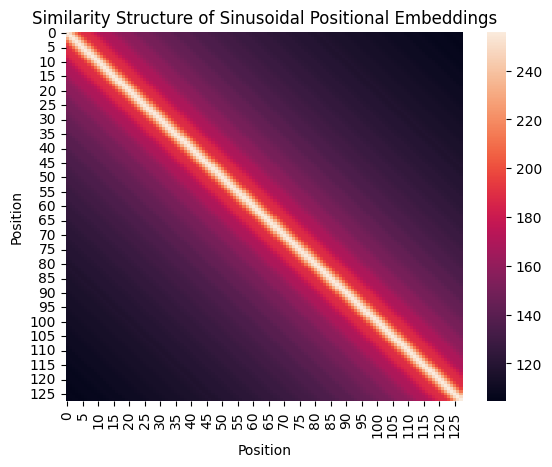

In [38]:
pe = get_sinusoidal_positional_embeddings(128, d_model)

#Your code here
pe_similarity = pe @ pe.T
sns.heatmap(pe_similarity)
plt.title('Similarity Structure of Sinusoidal Positional Embeddings')
plt.xlabel('Position')
plt.ylabel('Position')
plt.show()

[Your markdown here]

The heatmap is brightest along the diagonal (position $i$ is most similar to itself) and gradually fade as you move away from it: nearby positions have similar embeddings, distant positions less so.

I see oscillatory patterns because each dimension is a sine or cosine with different frequency. That creates repeating bands of similarity at different scales.

These embeddings are designed to encode both: Absolute position (each index has a unique vector), and relative position (differences $i - j$ correspond to predictable phase shifts in the sinusoids).

This works well in practice: the model can infer “how far apart” two tokens are from the pattern of their positional embeddings, and the sinusoidal form lets it generalize to longer sequences than seen in training.

### Multi-Head Attention

The core operation in a Transformer is multi-head attention, sometimes called self-attention. In this problem, we will implement multi-head attention in numpy from scratch, given the trained parameters of the model.

The input is a sequence of vectors $X = (x_1, ..., x_n) \in \reals^{n \times d_{model}}$. For each attention head $h \in [n_h]$, the parameters consist of a query projection matrix $W_q^h \in \reals^{d_{model} \times d_h}$, a key projection matrix $W_k^h \in \reals^{d_{model} \times d_h}$, and a value projection matrix $W_k^h \in \reals^{d_{model} \times d_h}$. Here, $d_h$ is the "head dimension", taken to be $d_{model} / n_h$ (to maintain the same dimensionality between the input and output). The algorithm, for each head, is the following:
1. Compute the queries $Q = X W_q^h$, keys $K = X W_k^h$, and values $V = X W_v^h$. Note that the linear maps are applied independently for each token across the embedding dimension (not sequence dimension), such that $Q, K, V \in \reals^{n \times d_h}$.
2. Compare the queries and keys via inner products to get an $n \times n$ attention matrix $A = \mathrm{Softmax}(Q K^{\intercal}) \in \reals^{n \times n}$.
3. Use the attention scores $A$ to select values, producing the output of the self-attention head: $\mathrm{head}_h = A V \in \reals^{n \times d_h}$.
We then concatenate the retrieved values across all heads, and apply a final linear map. Putting this all together yields:
$$
\begin{align}
    \mathrm{head}_h &= \mathrm{Softmax}((X W_q^h) (X W_k^h)^{\intercal}) X W_v^h\\
    \mathrm{MultiHeadAttention}(X) &= \mathrm{concat}(\mathrm{head}_1, ..., \mathrm{head}_{n_h}) W_o\\
\end{align}
$$

### Problem 2.4: Implement multi-head attention

In [39]:
# first, implement softmax and causal masking
def softmax(x, axis=-1):

    x_max = np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(x - x_max)
    sum_e_x = np.sum(e_x, axis=axis, keepdims=True)
    return e_x / sum_e_x

def apply_presoftmax_causal_mask(attn_scores):
    # apply a causal mask to the attention scores (set the entries above the diagonal to -inf)

    # your code here

    n = attn_scores.shape[0]
    # mask of positions to set to -inf: i < j (strictly upper triangle)
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    attn_scores = attn_scores.copy()
    attn_scores[mask] = -np.inf
    return attn_scores

In [40]:
# check your implementation
x = np.ones((4,4))
softmax_x = softmax(x, axis=1)
print("Softmax:\n", softmax_x)

# apply_presoftmax_causal_mask test
attn_scores = np.ones((4,4))
masked_scores = apply_presoftmax_causal_mask(attn_scores)
print("Masked Attention Scores:\n", masked_scores)

masked_softmax = softmax(masked_scores, axis=-1)
print("Masked Softmax:\n", masked_softmax)

Softmax:
 [[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
Masked Attention Scores:
 [[  1. -inf -inf -inf]
 [  1.   1. -inf -inf]
 [  1.   1.   1. -inf]
 [  1.   1.   1.   1.]]
Masked Softmax:
 [[1.         0.         0.         0.        ]
 [0.5        0.5        0.         0.        ]
 [0.33333333 0.33333333 0.33333333 0.        ]
 [0.25       0.25       0.25       0.25      ]]


Expected results:
```
Softmax:
 [[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
Masked Attention Scores:
 [[  1. -inf -inf -inf]
 [  1.   1. -inf -inf]
 [  1.   1.   1. -inf]
 [  1.   1.   1.   1.]]
Masked Softmax:
 [[1.         0.         0.         0.        ]
 [0.5        0.5        0.         0.        ]
 [0.33333333 0.33333333 0.33333333 0.        ]
 [0.25       0.25       0.25       0.25      ]]
```

In [41]:

def multi_head_attention(x, params, layer_prefix='layers.0'):
    """
    Compute multi-head self-attention.

    Args:
        x (np.array): input tensor, shape (n, d_model)
        params (dict): dictionary containing the model parameters
        layer_prefix (str): prefix of parameter names corresponding to the layer
        verbose (bool): whether to print intermediate shapes
    """

    # get parameters of multi-head attention layer
    wq = params[f'{layer_prefix}.attention.wq.weight'].T # (d_model, d_model)
    wk = params[f'{layer_prefix}.attention.wk.weight'].T # (d_model, d_model)
    wv = params[f'{layer_prefix}.attention.wv.weight'].T # (d_model, d_model)
    wo = params[f'{layer_prefix}.attention.wo.weight'].T # (d_model, d_model)

    head_dim = d_model // n_heads # dimension of each head
    attn_scale = 1 / math.sqrt(head_dim) # scaling factor for attention scores

    # the wq, wk, wv, wo matrices contain weights for all heads, concatenated
    # first, we split wq, wk, wv, wo into heads
    # note: there are more efficient implementations, but this is more verbose/pedagogical
    wq = wq.reshape(d_model, n_heads, head_dim).transpose(1, 0, 2) # (n_heads, d_model, head_dim)
    wk = wk.reshape(d_model, n_heads, head_dim).transpose(1, 0, 2) # (n_heads, d_model, head_dim)
    wv = wv.reshape(d_model, n_heads, head_dim).transpose(1, 0, 2) # (n_heads, d_model, head_dim)

    head_outputs = []
    for head in range(n_heads):

        # get head-specific parameters (these are the query/key/value projections for this head)
        # your code ehre
        wqh = wq[head] # (d_model, head_dim)
        wkh = wk[head] # (d_model, head_dim)
        wvh = wv[head] # (d_model, head_dim)

        # compute queries, keys, values
        # your code here
        q = x @ wqh
        k = x @ wkh
        v = x @ wvh

        # compute attention scores
        # your code here
        # compute dot product
        attn_scores = q @ k.T
        # multiply by scaling factor
        attn_scores = attn_scores * attn_scale # (n, n)

        # apply causal mask
        attn_scores = apply_presoftmax_causal_mask(attn_scores)
        # apply softmax
        attn_scores = softmax(attn_scores, axis=-1)

        # apply attention scores to values
        # your code here
        head_out = attn_scores @ v

        # store the head output
        head_outputs.append(head_out)

    # concatenate all head outputs
    head_outputs = np.concatenate(head_outputs, axis=-1)

    # apply output linear map W_o to concatenated head outputs
    # your code here
    output = head_outputs @ wo

    return output

#### Test your Attention implementation

To test if you have the correct implementation, you can run the following
test line. We show the expected output if your implementation is correct.

In [42]:
multi_head_attention(np.ones((block_size, d_model)), transformer_model_weights)[:3, :5]

array([[-0.61194002, -0.31581021,  0.17525476, -0.03176344,  0.23671877],
       [-0.61194002, -0.31581021,  0.17525476, -0.03176344,  0.23671877],
       [-0.61194002, -0.31581021,  0.17525476, -0.03176344,  0.23671877]])

Expected output:

```
array([[-0.61194002, -0.31581021,  0.17525476, -0.03176344,  0.23671877],
       [-0.61194002, -0.31581021,  0.17525476, -0.03176344,  0.23671877],
       [-0.61194002, -0.31581021,  0.17525476, -0.03176344,  0.23671877]])
```

### MLP

Each Transformer layer (i.e., block) consists of two operations: 1) (multi-head) self-attention, which enables exchange of information between tokens, and 2) a multi-layer perceptron, which processes each token independently. A Transformer model is essentially just alternating between these two operations. In this problem, we will implement the multi-layer perceptron step. Typically, the MLP at each layer is simply a two-layer (one hidden layer) MLP or Feed Forward Network. In our model, we use a ReLU activation in the hidden layer, though other activations are possible. The same MLP network is applied to each token embedding in the sequence independently.

Given $X = (x_1, ..., x_n) \in \reals^{n \times d_{model}}$, we apply the MLP as follows:

$$\mathrm{MLP}(X) = \mathrm{ReLU}(X W_1) W_2$$

Note that we don't use biases for simplicity.

### Problem 2.5: Implement the MLP

Next, we need to apply the multi-layer perceptron in each layer. Complete the implementation below.

In [43]:
def relu(x):
    return np.maximum(x, 0)

def mlp(x, params, layer_prefix='layers.0'):
    # get MLP parameters
    w1 = params[f'{layer_prefix}.feed_forward.0.weight'].T # (d_model, d_ff)
    w2 = params[f'{layer_prefix}.feed_forward.2.weight'].T # (d_ff, d_model)

    # Your code here
    h = relu(x @ w1)   # (n, d_ff)
    o = h @ w2         # (n, d_model)

    return o

#### Test your MLP implementation

To test if you have the correct MLP implementation, you can run the following
test line. We show the expected output if your implementation is correct.

In [44]:
mlp(np.ones((block_size, d_model)), transformer_model_weights)[:3, :5]

array([[ 0.36650751, -0.02109491,  0.13528369, -0.0459696 ,  0.2035102 ],
       [ 0.36650751, -0.02109491,  0.13528369, -0.0459696 ,  0.2035102 ],
       [ 0.36650751, -0.02109491,  0.13528369, -0.0459696 ,  0.2035102 ]])

Expected output:

```
array([[ 0.36650751, -0.02109491,  0.13528369, -0.0459696 ,  0.2035102 ],
       [ 0.36650751, -0.02109491,  0.13528369, -0.0459696 ,  0.2035102 ],
       [ 0.36650751, -0.02109491,  0.13528369, -0.0459696 ,  0.2035102 ]])
```

### Problem 2.6: Implement Layer Normalization

Layer Normalization is a technique that normalizes the inputs across the features of a layer to stabilize and accelerate training in deep neural networks. It rescales activations to have zero mean and unit variance *within* each layer, then applies a learned gain and shift. In Transformers, LayerNorm is applied before or after sublayers (like attention and feedforward blocks), stabilizing training and maintaining consistent scaling across tokens and layers.

In this problem, we will implement layer normalization. For a vector of activations $x \in \reals^d$, layer normalization returns the normalized feature vector
$$\mathrm{LayerNorm}(x) = \frac{x - E[X]}{\sqrt{\mathrm{Var}[x] + \epsilon}} * \gamma + \beta,$$
where $\gamma \in \reals^d$ is the weight parameter, and $\beta \in \reals^d$ is the bias parameter. Here, $E[\cdot]$ and $\mathrm{Var}[\cdot]$ indicates the mean and variance over the embedding dimension $d_{\mathrm{model}}$.

In [45]:
def layer_norm(x, params, layer_prefix='layers.0', norm_type='attn_norm', norm_eps=1e-5):
    # get layer norm params
    weight = params[f'{layer_prefix}.{norm_type}.weight'] # (d_model,)
    bias = params[f'{layer_prefix}.{norm_type}.bias'] # (d_model,)

    mean = x.mean(axis=-1, keepdims=True)          # (n, 1)
    var  = x.var(axis=-1, keepdims=True)           # (n, 1)

    # normalize
    x_hat = (x - mean) / np.sqrt(var + norm_eps)   # (n, d_model)

    # scale and shift (broadcast weight and bias)
    normed_x = x_hat * weight + bias              # (n, d_model)

    return normed_x

#### Test your LayerNorm implementation

To test if you have the correct LayerNorm implementation, you can run the following test line. We show the expected output if your implementation is correct.

In [46]:
layer_norm(np.arange(block_size * d_model).reshape(block_size, d_model), transformer_model_weights, layer_prefix='layers.0', norm_type='attn_norm')[:3, :5]

array([[-1.76364724, -1.75155978, -1.7455241 , -1.74605486, -1.72934376],
       [-1.76364724, -1.75155978, -1.7455241 , -1.74605486, -1.72934376],
       [-1.76364724, -1.75155978, -1.7455241 , -1.74605486, -1.72934376]])

Expected Output:
```
array([[-1.76364724, -1.75155978, -1.7455241 , -1.74605486, -1.72934376],
       [-1.76364724, -1.75155978, -1.7455241 , -1.74605486, -1.72934376],
       [-1.76364724, -1.75155978, -1.7455241 , -1.74605486, -1.72934376]])
```

### Problem 2.7: Exploring Normalization in Residual Architectures

Transformers are a type of *residual network*. At each layer, the embeddings of each token are iteratively refined by adding the result of a non-linear learnable transformation (either attention or MLP). In general, a residual architecture has the form
$$x^{(\ell + 1)} = x^{(\ell)} + \mathcal{F}(x^{(\ell)}),$$
where $x^{(\ell)}$ is the internal representation at layer $\ell$ and $\mathcal{F}(\cdot)$ is a learned transformation. You can think of $\mathcal{F}(\cdot)$ as modeling the *residual* $x^{(\ell)} \mapsto x^{(\ell + 1)} - x^{(\ell)}$ rather than needing to directly model the full $x^{(\ell)} \mapsto x^{(\ell + 1)}$ map. This improves training stability and mitigates vanishing gradient problems.

There are different ways that normalization can be applied to residual networks. The form above includes no normalization.

In the original Transformer paper, the authors use so-called "post-normalization", where the normalization is applied *after* the residual block:
$$x^{(\ell + 1)} = \mathrm{LayerNorm}(x^{(\ell)} + \mathcal{F}(x^{(\ell)})).$$

In modern architectures, it is more common to use "pre-normalization", where the normalization before the learned transformation:
$$x^{(\ell + 1)} = x^{(\ell)} + \mathcal{F}(\mathrm{LayerNorm}(x^{(\ell)})).$$

In this problem, we will explore the effects of normalization on the magnitude of the feature vectors at each layer. Complete the code below to implement each form of normalization: 1) no norm, 2) post-norm, 3) pre-norm. Plot the average embedding norm across layers for each form of normalization. Interpret the results. Does this shed light onto why normalization is a useful empirical technique to stabilize and accelerate training?

In [ ]:
d_model = 512
n_layers = 4
n_heads = 8
d_ff = 4 * d_model
vocab_size = 1024
block_size = 128

model_name = f'BardGPT_weights_D{d_model}L{n_layers}H{n_heads}.npy'
transformer_model_weights = np.load(data_path + '/transformer_problem/' + model_name, allow_pickle=True).item()

In [49]:
# Experiment: compare NoNorm, Pre-LN, Post-LN for a stack of feedforward blocks
np.random.seed(0)

seq_len = block_size
#d_model = D
#d_ff = F * D
n_layers_exp = 24

# shared random input X0
X0 = np.random.randn(seq_len, d_model)

def simple_layer_norm(x, eps=1e-5):
    # for purposes of exploration, implement a simple layer norm with weight = 1 and bias = 0

    # your code here
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    # normalized, with gamma=1, beta=0
    norm_x = (x - mean) / np.sqrt(var + eps)
    return norm_x

# random FFN blocks to play the role of $\mathcal{F}$
# initialize independent W1/W2 per layer
W1_list = [np.random.randn(d_model, d_ff) * (1.0 / np.sqrt(d_model)) for _ in range(n_layers_exp)]
W2_list = [np.random.randn(d_ff, d_model) * (1.0 / np.sqrt(d_ff)) for _ in range(n_layers_exp)]

def ffn(x, W1, W2):
    return relu(np.dot(x, W1)).dot(W2)

In [50]:
# complete the implementation
def run_scheme(scheme_name):
    x = X0.copy()
    norms = [np.mean(np.linalg.norm(x, axis=1))]  # layer 0
    for i in range(n_layers_exp):
        W1, W2 = W1_list[i], W2_list[i]
        # residual without normalization
        if scheme_name == 'no_norm':
            x = x + ffn(x, W1, W2)

        # apply "pre-norm" normalization
        elif scheme_name == 'pre_ln':
            x = x + ffn(simple_layer_norm(x), W1, W2)

        # apply "post-norm" normalization
        elif scheme_name == 'post_ln':
            x = simple_layer_norm(x + ffn(x, W1, W2))
        else:
            raise ValueError(scheme_name)

        # compute norm of each token embedding at current layer
        avg_norm_this_layer = np.mean(np.linalg.norm(x, axis=1)) # your code here
        norms.append(avg_norm_this_layer)
    return np.array(norms)

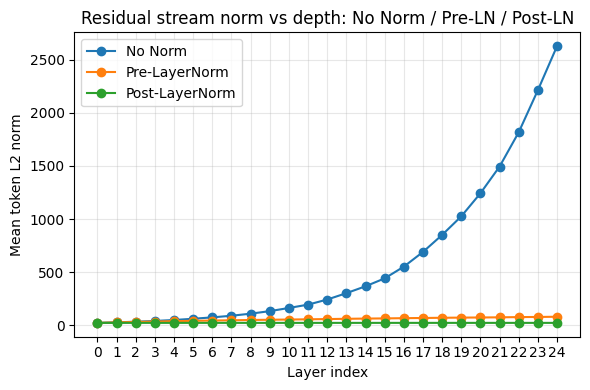

In [51]:

schemes = ['no_norm', 'pre_ln', 'post_ln']
results = {s: run_scheme(s) for s in schemes}

# Plot
plt.figure(figsize=(6,4))
layers = np.arange(0, n_layers_exp + 1)
plt.plot(layers, results['no_norm'], marker='o', label='No Norm')
plt.plot(layers, results['pre_ln'], marker='o', label='Pre-LayerNorm')
plt.plot(layers, results['post_ln'], marker='o', label='Post-LayerNorm')
plt.xlabel('Layer index')
plt.ylabel('Mean token L2 norm')
plt.title('Residual stream norm vs depth: No Norm / Pre-LN / Post-LN')
plt.xticks(layers)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

[Your Markdown Here]

No Norm: the mean L2 norm grows explosively with depth This shows how residual stacks can become unstable without any normalization.

Pre-LN: the norms stay relatively stable across layers, because every block sees a normalized input and then adds a residual of controlled scale. This is why pre-norm Transformers train very stably and handle deep stacks well.

Post-LN: the norm is “reset” after each residual, so it also stays bounded, but gradients have to pass through the LayerNorm, which can make optimization a bit trickier than pre-LN.

Overall, normalization keeps the residual stream from blowing up or vanishing as you go deeper, which helps stabilize and speed up training.

### Final Prediction Layer

A Transformer model iteratively applies multi-head attention and MLP layers to process the input. This produces a processed representation of shape $n \times d_{model}$. To make the final prediction (e.g., predict the next token), we need to map the $d_{model}$-dimensional embedding vectors to logits over the output vocabulary. To do this, we simply apply a linear map that maps from $d_{model}$ to $\mathtt{vocab\_size}$.

The starter code for this is given below; you need to complete it.

### Problem 2.8: Implement the prediction layer as logits.

In [52]:
def prediction_head(x, params):
    # get needed parameters
    w = params['fc_out.weight'].T # (d_model, vocab_size)
    b = params['fc_out.bias'] # (vocab_size,)

    # Your code here
    logits = x @ w + b

    return logits

### Test the prediction head

In [53]:
prediction_head(np.ones((block_size, d_model)), transformer_model_weights)[:3, :5]

array([[-1.52472634, -0.92704511, -0.07956709, -0.27001108, -0.2583226 ],
       [-1.52472634, -0.92704511, -0.07956709, -0.27001108, -0.2583226 ],
       [-1.52472634, -0.92704511, -0.07956709, -0.27001108, -0.2583226 ]])

```
array([[-1.52472634, -0.92704511, -0.07956709, -0.27001108, -0.2583226 ],
       [-1.52472634, -0.92704511, -0.07956709, -0.27001108, -0.2583226 ],
       [-1.52472634, -0.92704511, -0.07956709, -0.27001108, -0.2583226 ]])
```

### Putting it all together: A Full Transformer Language Model

We are now ready to put this all together to assemble our Transformer Language Model. Recall that the Transformer architecture consists of iteratively applying multi-head attention and MLPs. Each time we apply attention or the MLP, we also apply a *residual connection*: $X^{(\ell + 1)} = X^{(\ell)} + F(X^{(\ell)})$. This can be interpreted as a mechanism to enable easy communication between different layers (some people call refer to this idea as the "residual stream"). Real Transformers also include layer normalization in each layer, but we omit this for simplicity in this problem.

The full algorithm is given below:
1. Embed the tokens using the embedding lookup table: $(t_1, ..., t_n) \mapsto (E_{t_1}, ..., E_{t_n}) =: X^{(0)}$
2. Add the positional embeddings: $X^{(0)} \gets X^{(0)} + (PE_1, ..., PE_n)$
3. For each layer $\ell = 1, ..., L$:
    1. Apply Multi-Head Attention: $\tilde{X}^{(\ell)} \gets X^{(\ell-1)} + \mathrm{MultiHeadAttention}(\mathrm{LayerNorm}(X^{(\ell-1)}))$.
    2. Apply the MLP: $X^{(\ell)} \gets \tilde{X}^{(\ell)} + \mathrm{MLP}(\mathrm{LayerNorm}(\tilde{X}^{(\ell)}))$.
4. Compute the logits

### Problem 2.9: Complete the implementation

Complete the starter code below, which takes embeddings, adds positional encoding,
and then adds the attention and MLP components to each layer. Remember that
everything is added together, with the computations in one layer added to the outputs of the previous layer, forming the "residual stream".

Hint: to complete the implementation, you will need to use the `layer_norm`, `multi_head_attention`, `mlp`, and `prediction_head` functions you implemented above. Recall that these functions take `param` as input (which are the weights of the pre-trained model). They use the `layer_prefix` argument to fetch the weights at the given layer. For example, `layer_prefix=f'layers.{i}'` will the corresponding module for layer `i`. Additionally, since each layer has two LayerNorms, one for the attention module and one for the MLP module, the `layer_norm` function additionally takes `norm_type` argument, which can be `'attn_norm'` or `'ff_norm'`.

In [56]:
def transformer(tokens, params):
    # tokens: (n,) integer array
    # params: dictionary of parameters

    # map tokens to embeddings using embed_tokens
    x = embed_tokens(tokens, params) # (n, d_model)

    # add positional embeddings
    pe = get_sinusoidal_positional_embeddings(x.shape[0], x.shape[1]) # (n, d_model)
    # your code here
    x = x + pe # (n, d_model)

    # transformer blocks
    for i in range(n_layers):
        layer_prefix = f'layers.{i}'

        # compute multi-head self-attention and add residual with pre-normalization
        # your code here
        normed_x = layer_norm(x, params, layer_prefix=layer_prefix, norm_type='attn_norm')
        attn_out = multi_head_attention(normed_x, params, layer_prefix=layer_prefix)
        x = x + attn_out  # residual

        # compute MLP and add residual with pre-normalization
        # your code here
        normed_x = layer_norm(x, params, layer_prefix=layer_prefix, norm_type='ff_norm')
        mlp_out = mlp(normed_x, params, layer_prefix=layer_prefix)
        x = x + mlp_out  # residual

    # compute logits via the prediction_head
    # your code here
    logits = prediction_head(x, params)

    return logits

### Test your implementation

You can check your implementation against the expected output below.

In [57]:
transformer([0, 1, 2], params=transformer_model_weights)[:3, :5]

array([[-3.30795907, -1.9419719 , -0.67287022, -1.71627247, -1.54158904],
       [-4.15893293, -1.83363694, -2.26268612, -2.63614069, -2.48212268],
       [-3.51487281, -2.31248407, -3.52562579, -3.18057024, -1.76104192]])

Expected Output:

```
array([[-3.30795902, -1.94197185, -0.67287023, -1.7162725 , -1.541589  ],
       [-4.15893294, -1.8336369 , -2.26268609, -2.63614073, -2.48212268],
       [-3.51487274, -2.31248397, -3.52562574, -3.18057025, -1.76104193]])
``````

### Generate some text

Below, we provide some code for generating text from a Transformer language model. The sampling procedure is *autoregressive*. This means that we input some text to the model and it outputs a distribution over next tokens. We sample the next token and append it to the text, then repeat the procedure.

### Problem 2.10: Complete the next token generator

Complete the next token generator, but filling in the missing code below. This uses "temperature" to focus on the more probable tokens in a given context (as the temperature decreases).

In [64]:
def generate_with_transformer(prefix_text, params, max_len=128, greedy=False, temperature=0.9):
    # encode seed text
    prefix_tokens = list(enc.encode(prefix_text))

    # initialize generated tokens
    generated_tokens = prefix_tokens

    # generate new tokens
    for i in range(max_len):
        # predict next token
        logits = transformer(generated_tokens, params)
        next_logits = logits[-1]  # prediction for next token
        # hint: logits[-1] corresponds to prediction of the next token
        if greedy:
            # Your code here
            next_token = int(np.argmax(next_logits))
        else:
            # Your code here
            probs = softmax(next_logits / temperature, axis=-1)
            next_token = int(np.random.choice(len(probs), p=probs))

        # add next token to generated tokens
        generated_tokens.append(next_token)

    # This converts the tokens to text, using the tiktoken decoder:
    generated_text = enc.decode(generated_tokens)

    return generated_text

### Test your implementation by generating text. You're the Bard!

Use your implementation to generate text according to the model. Generate text at different temperatures. Do the results make sense? Comment on the quality of the model. What changes to the model would lead to better results? Comment in the Markdown cell below.

In [65]:
 prefix_text = """STUDENT:
 O though Transformer, wrought of mind and code,
 Thou art the loom where language weaveth thought!
 Each token, like a spark of meaning sown,
 Attendeth all, and all attend to one."""

#prefix_text = """HAMLET:
#To be, or not to be: that is the question"""

In [66]:
generated_text = generate_with_transformer(prefix_text, transformer_model_weights, greedy=True, max_len=128)
print(generated_text)

STUDENT:
O though Transformer, wrought of mind and code,
Thou art the loom where language weaveth thought!
Each token, like a spark of meaning sown,
Attendeth all, and all attend to one.



Second Citizen:
Well, sir;
What he's the belly.
Second Citizen:
Well, what then?
First Citizen:
First Citizen:
First Citizen:


If you'll batriciusers, what he hath alre's answer.



If I'll hear, what he hath done fell, what he hath done fell, what answer agused men can bell:

If I'll hear the bell:
If you must not masters


In [67]:
generated_text = generate_with_transformer(prefix_text, transformer_model_weights,
    greedy=False, temperature=0.8, max_len=128)
print(generated_text)

STUDENT:
O though Transformer, wrought of mind and code,
Thou art the loom where language weaveth thought!
Each token, like a spark of meaning sown,
Attendeth all, and all attend to one.

Second Citizen:
What accountry heard it.

cormall--
What would all the belly say you have help in the body say he should famous mutinion.
If you have baturerously-cons him you have

There was answer.
That,
The for the belly was for his counown to the body was deliberate, even tailant eye is the Citizen:
That, my good friends, they did


[Your markdown here]

At greedy decoding (or very low temperature), the model produces text that is
clearly Shakespeare-like in style (stage directions, speakers, archaic
vocabulary and rhythm), but it quickly becomes repetitive (`First Citizen:`
repeated) and gets stuck in local patterns. This makes sense: greedy decoding
always picks the single most likely next token, so once it falls into a loop
there is no randomness to escape.

At moderate temperature (e.g. `temperature = 0.8`), the samples are more
varied and creative. The model often produces plausible-sounding Elizabethan
phrases and dialogue structure, though the semantics are still quite shaky:
sentences drift, some words are nonsense (“baturerously”), and long-range
coherence is weak. Higher temperatures would add more diversity but quickly
degenerate into gibberish; lower temperatures approach the greedy behavior.

Overall, the model has learned local style and syntax reasonably well, but
global coherence and factual meaning are limited, which is expected for a
small Transformer trained only on Shakespeare.

To improve quality, we would want (among other things):

- Bigger model: larger $d_{\text{model}}$, more layers $L$, larger FFN
  width $d_{\text{ff}}$, possibly more heads.
- More and better data: train on more text (and/or more epochs) so the
  model sees more diverse patterns.
